# Predictive Analysis of Interview Success
## Using Linear and Logistic Regression

**Dataset:** Campus Placement Data (10,000 students)  
**Target Variables:**
- **Linear Regression:** Predict `AptitudeTestScore` (continuous)
- **Logistic Regression:** Predict `PlacementStatus` (Placed / NotPlaced)

---
## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Cell 2 — Load Dataset

In [2]:
df = pd.read_csv('placementdata.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 Rows:')
df.head()

Dataset Shape: (10000, 12)

First 5 Rows:


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


---
## Cell 3 — Dataset Overview

In [3]:
print('=== Column Info ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Placement Status Distribution ===')
print(df['PlacementStatus'].value_counts())
print('\n=== Placement Rate ===')
placed_pct = (df['PlacementStatus'] == 'Placed').mean() * 100
print(f'{placed_pct:.2f}% students were Placed')

=== Column Info ===
StudentID                      int64
CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus               object
dtype: object

=== Missing Values ===
StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

=== Placement Status Distribution ===
PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: in

---
## Cell 4 — Descriptive Statistics

In [4]:
df.describe(include='all')

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000.000000,10000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,NaN,NaN,NotPlaced
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5854,7318,NaN,NaN,5803
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,NaN,NaN,69.159400,74.501500,NaN
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,NaN,NaN,10.430459,8.919527,NaN
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,NaN,NaN,55.000000,57.000000,NaN
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,NaN,NaN,59.000000,67.000000,NaN
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,NaN,NaN,70.000000,73.000000,NaN
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,NaN,NaN,78.000000,83.000000,NaN


---
## Cell 5 — EDA: Placement Status Distribution

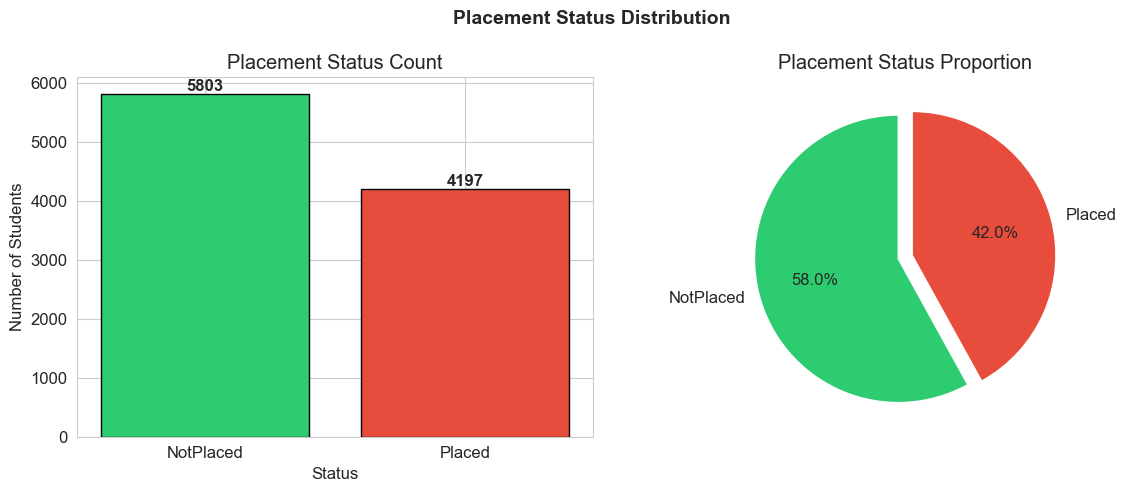

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['PlacementStatus'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Placement Status Count')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Placement Status Proportion')

plt.suptitle('Placement Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 6 — EDA: Numerical Feature Distributions

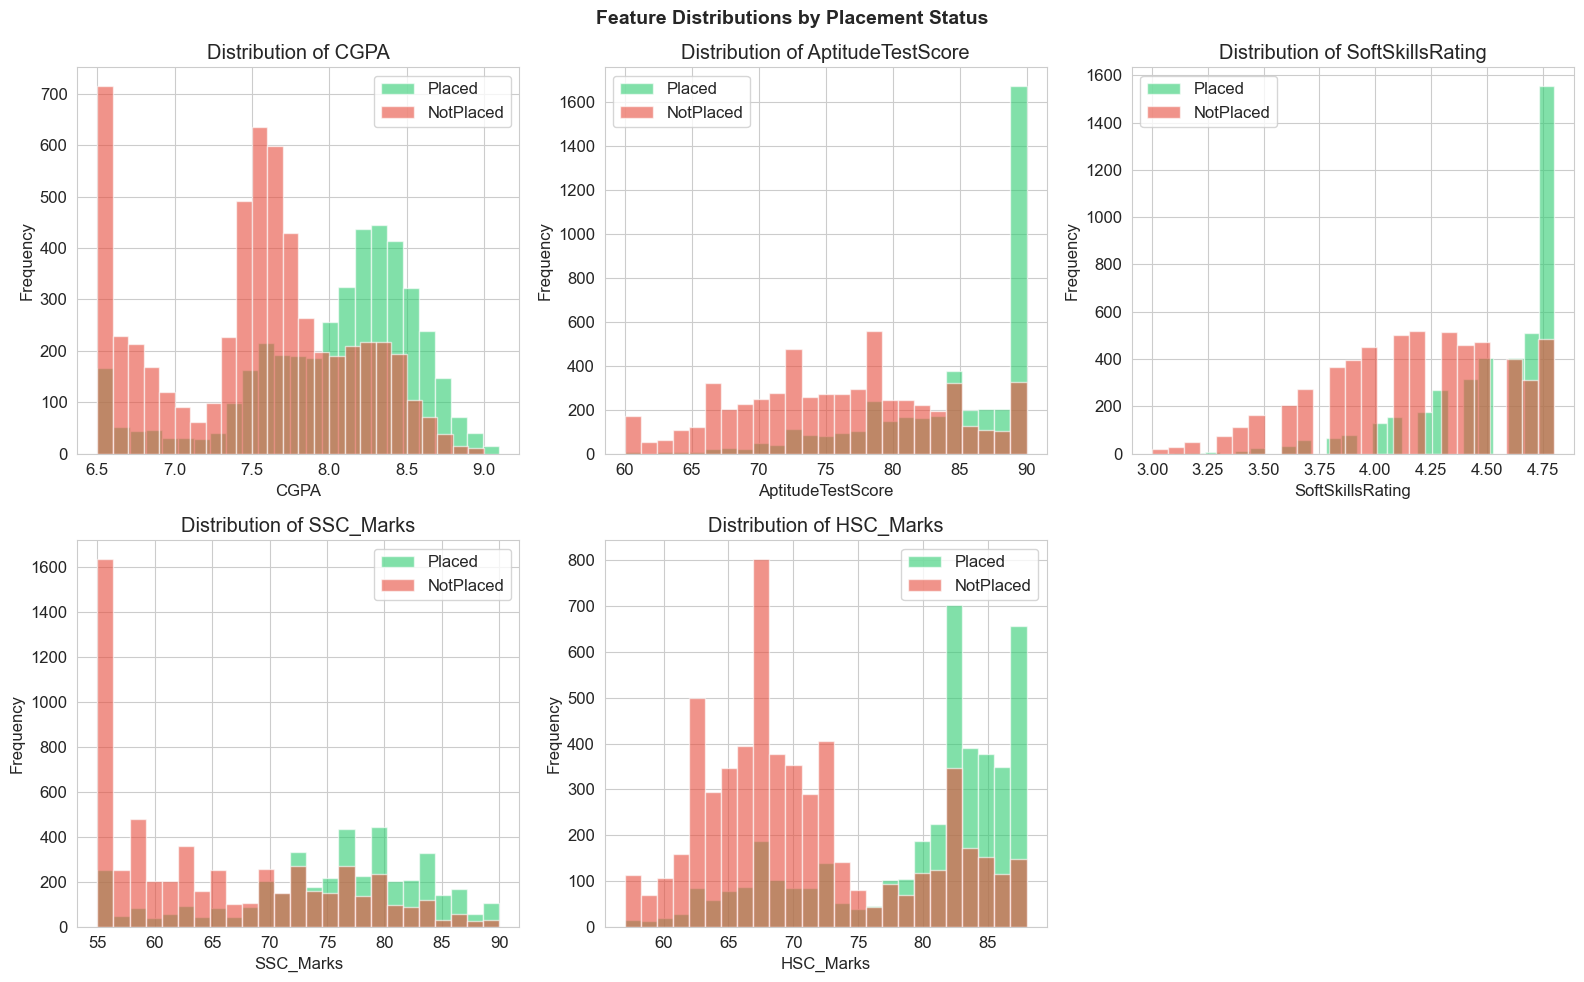

In [6]:
num_cols = ['CGPA', 'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for status, color in [('Placed', '#2ecc71'), ('NotPlaced', '#e74c3c')]:
        subset = df[df['PlacementStatus'] == status][col]
        axes[i].hist(subset, bins=25, alpha=0.6, label=status, color=color, edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

axes[-1].axis('off')  # hide empty subplot
plt.suptitle('Feature Distributions by Placement Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 7 — EDA: CGPA vs Placement (Boxplot)

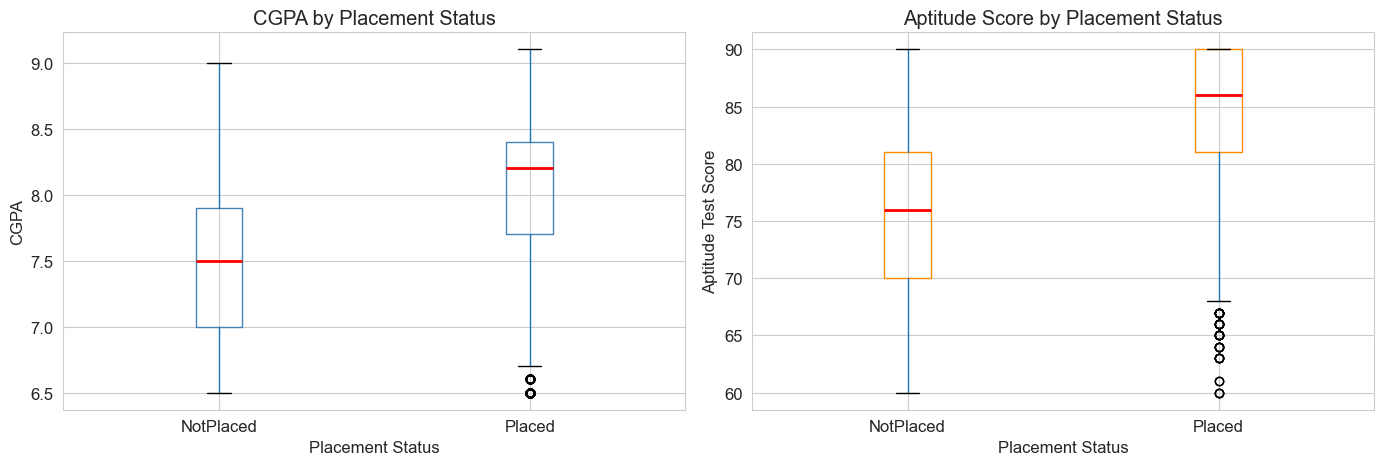

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: CGPA vs Placement
df.boxplot(column='CGPA', by='PlacementStatus', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('CGPA by Placement Status')
axes[0].set_xlabel('Placement Status')
axes[0].set_ylabel('CGPA')

# Boxplot: AptitudeTestScore vs Placement
df.boxplot(column='AptitudeTestScore', by='PlacementStatus', ax=axes[1],
           boxprops=dict(color='darkorange'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Aptitude Score by Placement Status')
axes[1].set_xlabel('Placement Status')
axes[1].set_ylabel('Aptitude Test Score')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## Cell 8 — EDA: Categorical Features vs Placement

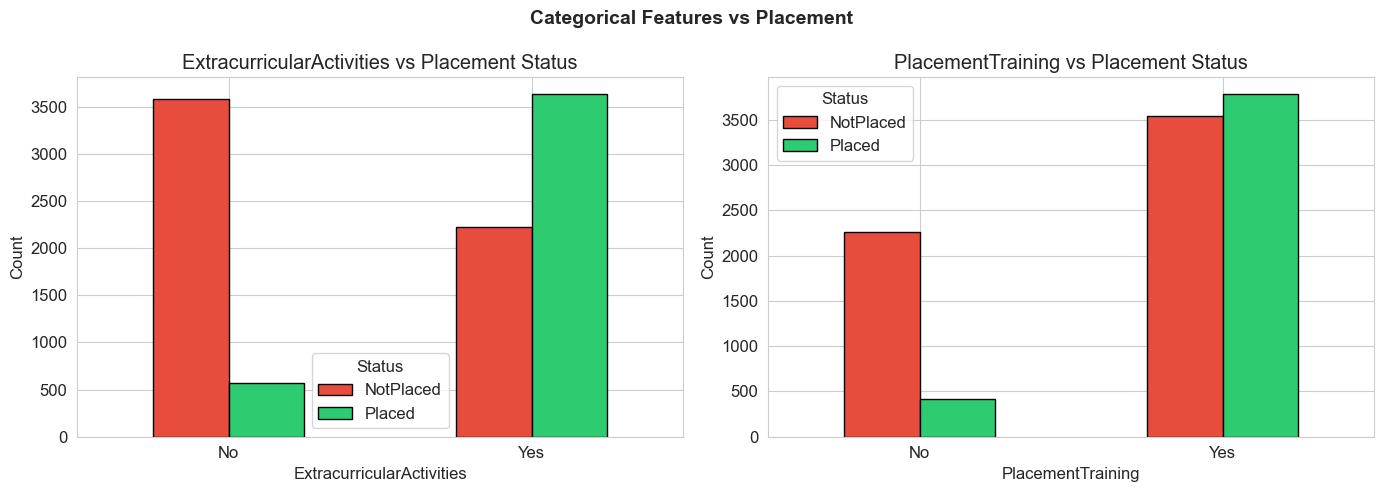

In [8]:
cat_cols = ['ExtracurricularActivities', 'PlacementTraining']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['PlacementStatus'])
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'],
            edgecolor='black', rot=0)
    axes[i].set_title(f'{col} vs Placement Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Status')

plt.suptitle('Categorical Features vs Placement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 9 — EDA: Correlation Heatmap

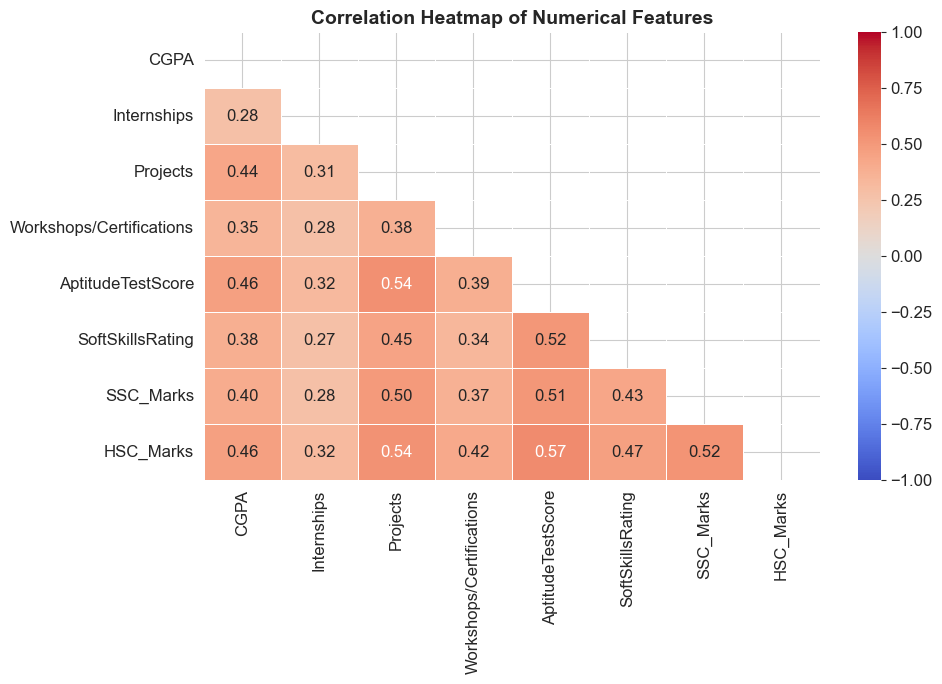

In [9]:
num_df = df.select_dtypes(include='number').drop(columns=['StudentID'])

plt.figure(figsize=(10, 7))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 10 — Data Preprocessing

In [10]:
df_model = df.copy()

# Encode binary categorical columns
le = LabelEncoder()
df_model['ExtracurricularActivities'] = le.fit_transform(df_model['ExtracurricularActivities'])  # Yes=1, No=0
df_model['PlacementTraining'] = le.fit_transform(df_model['PlacementTraining'])                  # Yes=1, No=0
df_model['PlacementStatus_bin'] = (df_model['PlacementStatus'] == 'Placed').astype(int)          # Placed=1

# Drop StudentID and original string target
df_model.drop(columns=['StudentID', 'PlacementStatus'], inplace=True)

print('Encoded DataFrame (first 3 rows):')
print(df_model.head(3))
print('\nColumns:', list(df_model.columns))

Encoded DataFrame (first 3 rows):
   CGPA  Internships  Projects  Workshops/Certifications  AptitudeTestScore  \
0   7.5            1         1                         1                 65   
1   8.9            0         3                         2                 90   
2   7.3            1         2                         2                 82   

   SoftSkillsRating  ExtracurricularActivities  PlacementTraining  SSC_Marks  \
0               4.4                          0                  0         61   
1               4.0                          1                  1         78   
2               4.8                          1                  0         79   

   HSC_Marks  PlacementStatus_bin  
0         79                    0  
1         82                    1  
2         80                    0  

Columns: ['CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_M

---
## Cell 11 — Define Features for Each Model

In [11]:
FEATURES = ['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
            'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining',
            'SSC_Marks', 'HSC_Marks']

# --- Linear Regression target: AptitudeTestScore ---
X_lin = df_model[FEATURES]
y_lin = df_model['AptitudeTestScore']

# --- Logistic Regression target: PlacementStatus (0/1) ---
X_log = df_model[FEATURES]
y_log = df_model['PlacementStatus_bin']

print('Feature matrix shape:', X_lin.shape)
print('Linear target (AptitudeTestScore) - sample:', y_lin.head(5).values)
print('Logistic target (PlacementStatus) - distribution:')
print(y_log.value_counts())

Feature matrix shape: (10000, 9)
Linear target (AptitudeTestScore) - sample: [65 90 82 85 86]
Logistic target (PlacementStatus) - distribution:
PlacementStatus_bin
0    5803
1    4197
Name: count, dtype: int64


---
## Cell 12 — Train-Test Split & Scaling

In [12]:
# Linear Regression split
X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42)

# Logistic Regression split
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log)

# Scale features
scaler_lin = StandardScaler()
X_lin_train_sc = scaler_lin.fit_transform(X_lin_train)
X_lin_test_sc  = scaler_lin.transform(X_lin_test)

scaler_log = StandardScaler()
X_log_train_sc = scaler_log.fit_transform(X_log_train)
X_log_test_sc  = scaler_log.transform(X_log_test)

print(f'Linear Regression  — Train: {X_lin_train_sc.shape}, Test: {X_lin_test_sc.shape}')
print(f'Logistic Regression — Train: {X_log_train_sc.shape}, Test: {X_log_test_sc.shape}')

Linear Regression  — Train: (8000, 9), Test: (2000, 9)
Logistic Regression — Train: (8000, 9), Test: (2000, 9)


---
## Cell 13 — Linear Regression: Train & Predict

In [13]:
lin_model = LinearRegression()
lin_model.fit(X_lin_train_sc, y_lin_train)

y_lin_pred = lin_model.predict(X_lin_test_sc)

# Evaluation
mae  = mean_absolute_error(y_lin_test, y_lin_pred)
mse  = mean_squared_error(y_lin_test, y_lin_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_lin_test, y_lin_pred)

print('=== Linear Regression — AptitudeTestScore Prediction ===')
print(f'  MAE  : {mae:.4f}')
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  R²   : {r2:.4f}')

# Coefficients
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lin_model.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print('\nFeature Coefficients:')
print(coef_df.to_string(index=False))

=== Linear Regression — AptitudeTestScore Prediction ===
  MAE  : 4.6581
  MSE  : 33.9314
  RMSE : 5.8251
  R²   : 0.4938

Feature Coefficients:
                  Feature  Coefficient
         SoftSkillsRating     1.522192
                HSC_Marks     1.467492
                 Projects     1.345893
                SSC_Marks     1.174423
                     CGPA     0.960541
        PlacementTraining     0.568066
 Workshops/Certifications     0.423681
              Internships     0.421364
ExtracurricularActivities     0.242131


---
## Cell 14 — Linear Regression: Visualisation

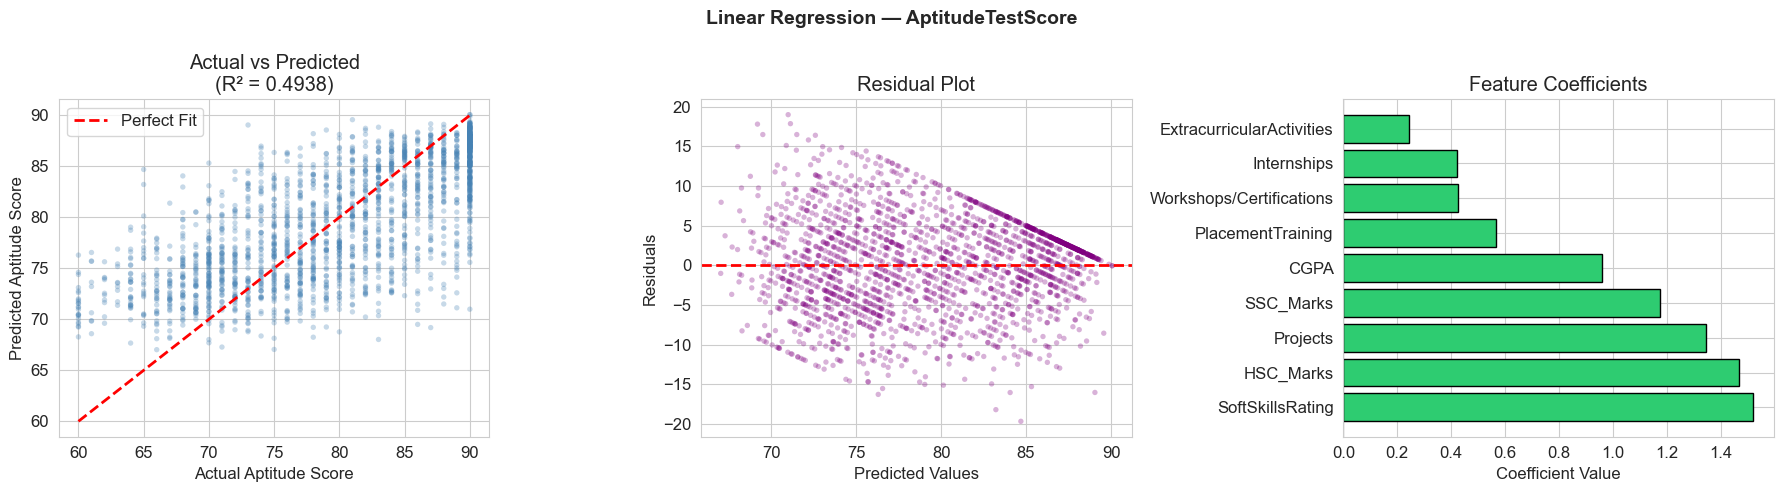

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Actual vs Predicted ---
axes[0].scatter(y_lin_test, y_lin_pred, alpha=0.3, color='steelblue', edgecolors='none', s=15)
mn, mx = y_lin_test.min(), y_lin_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Aptitude Score')
axes[0].set_ylabel('Predicted Aptitude Score')
axes[0].set_title(f'Actual vs Predicted\n(R² = {r2:.4f})')
axes[0].legend()

# --- Residuals ---
residuals = y_lin_test - y_lin_pred
axes[1].scatter(y_lin_pred, residuals, alpha=0.3, color='purple', edgecolors='none', s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

# --- Coefficient Bar Chart ---
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Feature Coefficients')
axes[2].set_xlabel('Coefficient Value')

plt.suptitle('Linear Regression — AptitudeTestScore', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 15 — Logistic Regression: Train & Predict

In [15]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_log_train_sc, y_log_train)

y_log_pred      = log_model.predict(X_log_test_sc)
y_log_prob      = log_model.predict_proba(X_log_test_sc)[:, 1]  # P(Placed)

acc     = accuracy_score(y_log_test, y_log_pred)
roc_auc = roc_auc_score(y_log_test, y_log_prob)

print('=== Logistic Regression — Placement Prediction ===')
print(f'  Accuracy : {acc:.4f}')
print(f'  ROC-AUC  : {roc_auc:.4f}')
print()
print(classification_report(y_log_test, y_log_pred, target_names=['NotPlaced', 'Placed']))

=== Logistic Regression — Placement Prediction ===
  Accuracy : 0.8055
  ROC-AUC  : 0.8817

              precision    recall  f1-score   support

   NotPlaced       0.84      0.83      0.83      1161
      Placed       0.76      0.77      0.77       839

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000



---
## Cell 16 — Logistic Regression: Confusion Matrix

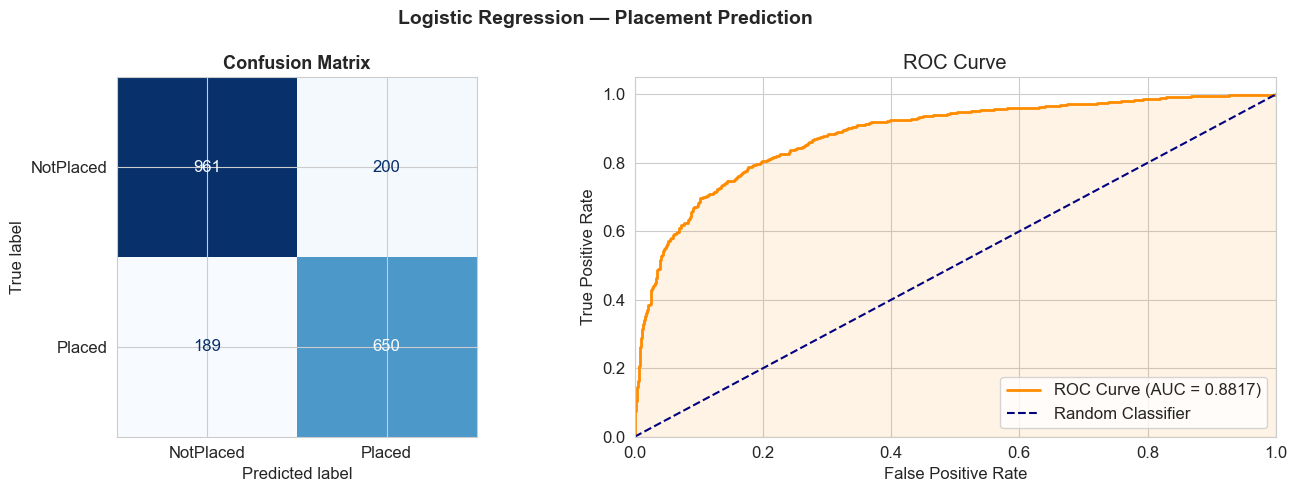

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_log_test, y_log_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NotPlaced', 'Placed'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_log_test, y_log_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.suptitle('Logistic Regression — Placement Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 17 — Logistic Regression: Feature Importance (Log-Odds)

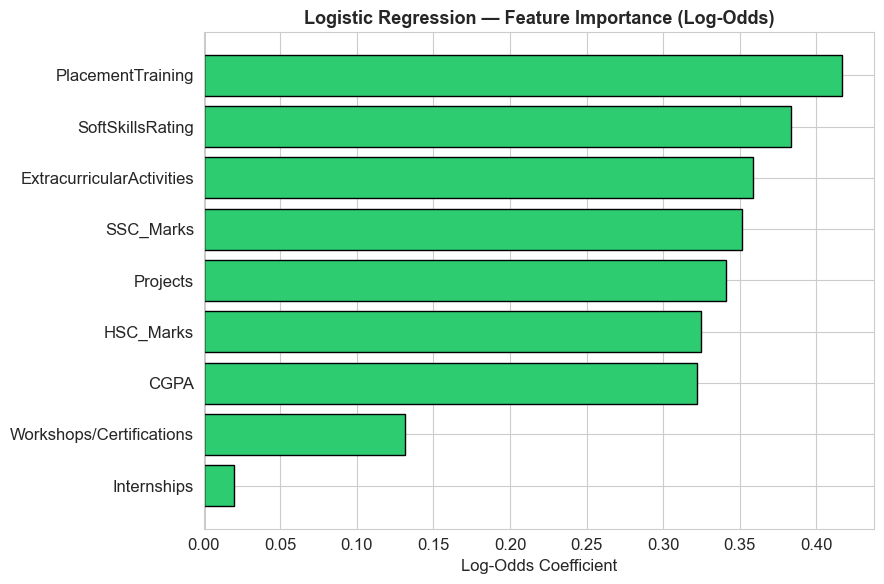

                  Feature  Log-Odds Coefficient
              Internships              0.019916
 Workshops/Certifications              0.131346
                     CGPA              0.322369
                HSC_Marks              0.324627
                 Projects              0.341199
                SSC_Marks              0.351333
ExtracurricularActivities              0.358892
         SoftSkillsRating              0.383500
        PlacementTraining              0.416903


In [17]:
log_coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Log-Odds Coefficient': log_model.coef_[0]
}).sort_values('Log-Odds Coefficient', ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in log_coef_df['Log-Odds Coefficient']]
plt.barh(log_coef_df['Feature'], log_coef_df['Log-Odds Coefficient'],
         color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Logistic Regression — Feature Importance (Log-Odds)', fontsize=13, fontweight='bold')
plt.xlabel('Log-Odds Coefficient')
plt.tight_layout()
plt.show()

print(log_coef_df.to_string(index=False))

---
## Cell 18 — Probability Distribution Plot

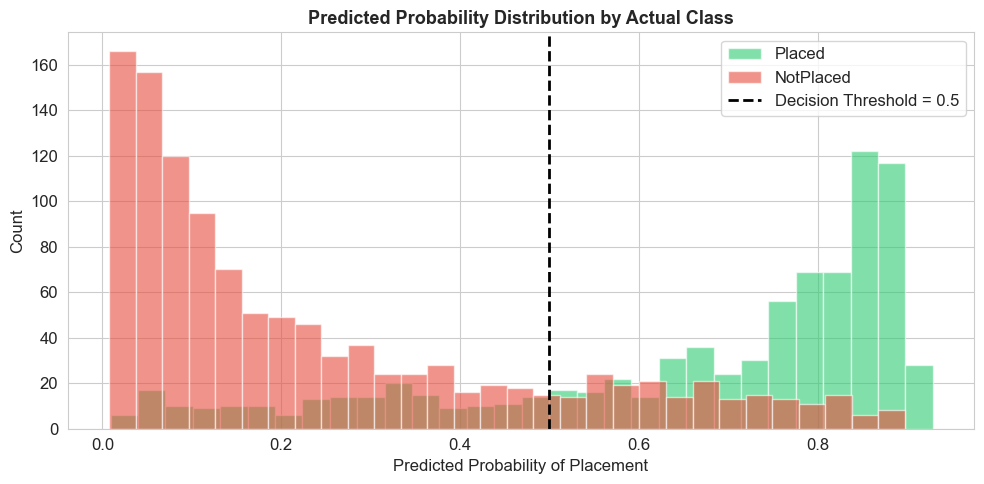

In [18]:
plt.figure(figsize=(10, 5))

for label, color, name in [(1, '#2ecc71', 'Placed'), (0, '#e74c3c', 'NotPlaced')]:
    idx = (y_log_test == label)
    plt.hist(y_log_prob[idx], bins=30, alpha=0.6, color=color,
             label=name, edgecolor='white')

plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold = 0.5')
plt.xlabel('Predicted Probability of Placement')
plt.ylabel('Count')
plt.title('Predicted Probability Distribution by Actual Class', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## Cell 19 — Model Comparison Summary

In [19]:
summary = {
    'Model': ['Linear Regression', 'Logistic Regression'],
    'Target': ['AptitudeTestScore', 'PlacementStatus'],
    'Task': ['Regression', 'Classification'],
    'Key Metric 1': [f'R² = {r2:.4f}', f'Accuracy = {acc:.4f}'],
    'Key Metric 2': [f'RMSE = {rmse:.4f}', f'ROC-AUC = {roc_auc:.4f}'],
    'Key Metric 3': [f'MAE = {mae:.4f}', f'F1-Score ≈ see report']
}

summary_df = pd.DataFrame(summary)
print('=== MODEL COMPARISON SUMMARY ===')
print(summary_df.to_string(index=False))

=== MODEL COMPARISON SUMMARY ===
              Model            Target           Task      Key Metric 1     Key Metric 2          Key Metric 3
  Linear Regression AptitudeTestScore     Regression       R² = 0.4938    RMSE = 5.8251          MAE = 4.6581
Logistic Regression   PlacementStatus Classification Accuracy = 0.8055 ROC-AUC = 0.8817 F1-Score ≈ see report


---
## Cell 20 — Predict for a New Student

In [20]:
# New student profile
new_student = pd.DataFrame([{
    'CGPA': 8.2,
    'Internships': 1,
    'Projects': 2,
    'Workshops/Certifications': 2,
    'SoftSkillsRating': 4.3,
    'ExtracurricularActivities': 1,  # Yes
    'PlacementTraining': 1,          # Yes
    'SSC_Marks': 78,
    'HSC_Marks': 82
}])

# Linear Regression prediction
new_scaled_lin = scaler_lin.transform(new_student)
predicted_score = lin_model.predict(new_scaled_lin)[0]

# Logistic Regression prediction
new_scaled_log = scaler_log.transform(new_student)
predicted_prob  = log_model.predict_proba(new_scaled_log)[0][1]
predicted_class = 'Placed' if predicted_prob >= 0.5 else 'NotPlaced'

print('=== PREDICTION FOR NEW STUDENT ===')
print(f'  Predicted Aptitude Test Score : {predicted_score:.2f}')
print(f'  Placement Probability         : {predicted_prob:.4f} ({predicted_prob*100:.1f}%)')
print(f'  Predicted Placement Status    : {predicted_class}')

=== PREDICTION FOR NEW STUDENT ===
  Predicted Aptitude Test Score : 83.28
  Placement Probability         : 0.7088 (70.9%)
  Predicted Placement Status    : Placed
